In [57]:
#Imports
import sys,os
os.environ['MKL_NUM_THREADS'] = '4' # set number of MKL threads to run in parallel
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from numpy.random import uniform,seed
from joblib import delayed,Parallel
from itertools import combinations
from functools import partial
import numpy as np
import gc
import pickle
from time import time
from quspin.tools.measurements import diag_ensemble
from quspin.tools.evolution import ED_state_vs_time
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, show, figure, xlabel, ylabel, xscale, yscale, legend, loglog
from numpy import pi, exp, log, sin , cos, tan, log, array
import quspin
timestamp = time()

In [ ]:
agp_string = r"$[\ \partial_g H , P_n ]\ $"
delta_string = r"$\Delta E$"


In [2]:
###Functions
def timer(timestamp):
    #Timer Function
    print("time =", time()-timestamp)
    return

def fin_string(ns,s): #ns = length of string s = operator
    #Max string length
    if ns>L:
        ns=L
    else:
        pass
    
    
    def linears(start,m):
        #Find all indices in string
        ind=[i%L for i in range(start,start+ns)]
     #All combinations
        perm=list(combinations(ind,m))
      #Add each coupling to operator
        for j in range(len(perm)):
#            S_temp=[((-1)**m)*(2**m)/(L*(2**ns))] ########### Down #
            S_temp=[1/(L*(2**ns))] ###################### Up
            for i in range(len(perm[j])):
                S_temp.append(perm[j][i])
        ##Saving Couplin gs lists
            if j==0: 
                S_temp_2=[S_temp]
            else: 
                S_temp_2.append(S_temp)
        return S_temp_2
    #List to store orders of interaction
    o_type=np.empty(ns,dtype=object)
    
    for i in range(ns):
        #ex: "z"*2= "zz"
        o_type[i]=s*(i+1)

    #Iterate over each Site
    for k in range(L):
        #Iterate over different string lengths
      for i in range(ns):
          #First item defines list
          if k==0 and i==0:
              #example: i = 0 operator_list = [['x', linears(k,1)]]
              operator_list=[[o_type[i],linears(k,i+1)]]
          else:
              operator_list.append([o_type[i],linears(k,i+1)])
    S_temp_1 = [[(1/((ns*2**ns))), i] for i in range(ns)]
    #S_temp_1 = [[(1/((ns*2**(ns)))), 1] ]
    operator_list.append(["I",S_temp_1])
    operator_dict=dict(S=operator_list)
    O = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    return O, operator_list

In [324]:
###### Model parameters
#Length of chain
L = 12
#X field
J1 = 1 #NN term 
J2 = 1
h0_list = [0.9,1,1.1]
#Basis being projected
op = "x"
ns = np.arange(1,11+1)


In [325]:
Vs = []
Es = []
V0s= []
Hs = []
 
for h0 in h0_list:
    ###Using Quantum_Operator to build hamitlonian 
    basis = spin_basis_1d(L, pauli = -1)
    #NN Sigma x term (Periodic Boundary Conditions)
    NN_sigma_x = [ [-J1, i, (i+1)%L] for i in range(L)]
    NNN_sigma_x = [ [-J2, i, (i+1)%L] for i in range(L)]

    #site coupling lists
    sigma_z = [ [-1, i] for i in range(L)]
    #Define the static H (that doesn't change)
    static_H = [ ["xx", NN_sigma_x], ["xx",NNN_sigma_x] ] 
    #The z field is the quench
    Quenching_H = [["z", sigma_z]]
    #Define operator dictionary
    operator_dict = dict(H0= static_H, Quench = Quenching_H)
    #Build Hamiltonian
    H = quantum_operator(operator_dict, basis=basis, check_herm= False, check_symm = False)
    #Define Parameters
    params_dict = dict( H0=1, Quench=h0)
    #Build H0
    H0 = H.tohamiltonian(params_dict)
    #Find eigenvalues
    E,V = np.linalg.eigh(H0.todense())
    #Convert matrix to array
    V = np.array(V)
    #Ground state of unquenched hamiltonian
    V0= V[:,0]
    D = len(V0)
    Vs.append(V)
    Es.append(E)
    V0s.append(V0)
    Hs.append(H0)

Ds= np.arange(D)




In [326]:
#Build Projectors
from tqdm import tqdm
Projectors = [array(fin_string(n,op)[0].todense()) for n in tqdm(ns)]




100%|██████████| 11/11 [09:52<00:00, 53.83s/it] 


In [327]:
#Compute AGP: 
AGP= [ [-1, i] for i in range(L)]
AGP = [["z", AGP]]
operator_dict=dict(S=AGP)
AGP= quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
A = array(AGP.todense())

In [328]:
A_basis = []
for V in Vs:
    A_expt  = np.zeros( D)

    for i in (range(D)):
        if i%50==0:
            print(i)
        Vi = V[:, i]
        V0 = V[:, 0]
        A_expt[i]= np.vdot(V0,A@Vi)
    A_basis.append(A_expt)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/981356328.py:10: RuntimeWarning: divide by zero encountered in matmul
  A_expt[i]= np.vdot(V0,A@Vi)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/981356328.py:10: RuntimeWarning: overflow encountered in matmul
  A_expt[i]= np.vdot(V0,A@Vi)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/981356328.py:10: RuntimeWarning: invalid value encountered in matmul
  A_expt[i]= np.vdot(V0,A@Vi)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/981356328.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  A_expt[i]= np.vdot(V0,A@Vi)


0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
2050
2100
2150
2200
2250
2300
2350
2400
2450
2500
2550
2600
2650
2700
2750
2800
2850
2900
2950
3000
3050
3100
3150
3200
3250
3300
3350
3400
3450
3500
3550
3600
3650
3700
3750
3800
3850
3900
3950
4000
4050
0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
2050
2100
2150
2200
2250
2300
2350
2400
2450
2500
2550
2600
2650
2700
2750
2800
2850
2900
2950
3000
3050
3100
3150
3200
3250
3300
3350
3400
3450
3500
3550
3600
3650
3700
3750
3800
3850
3900
3950
4000
4050
0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
2050
2100
2150
2200
2250
2300
2350
2400
2450

In [329]:
import numpy as np

P_basis = []                 # will hold arrays of shape (Nproj, D)
Nproj = len(Projectors)

for V in Vs:                 # V has shape (D, D)
    V0 = V[:, 0]             # ground state
    P_expt_all = np.zeros((Nproj, V.shape[1]), dtype=complex)

    for n, Pi in enumerate(Projectors):
        M = Pi @ V           # (D, D)
        P_expt_all[n, :] = np.conj(V0) @ M

    P_basis.append(P_expt_all)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/675846786.py:11: RuntimeWarning: divide by zero encountered in matmul
  M = Pi @ V           # (D, D)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/675846786.py:11: RuntimeWarning: overflow encountered in matmul
  M = Pi @ V           # (D, D)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/675846786.py:11: RuntimeWarning: invalid value encountered in matmul
  M = Pi @ V           # (D, D)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/675846786.py:12: RuntimeWarning: divide by zero encountered in matmul
  P_expt_all[n, :] = np.conj(V0) @ M
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/675846786.py:12: RuntimeWarning: overflow encountered in matmul
  P_expt_all[n, :] = np.conj(V0) @ M
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/675846786.py:12: RuntimeWarning: invalid value encountered in matmul
  P_expt_all[n, :] = np.conj(V0) @ M


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


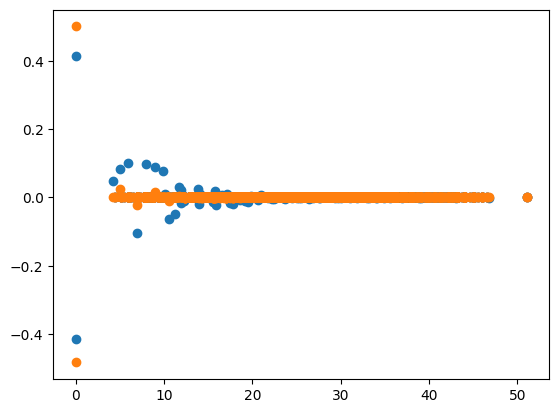

In [330]:
plt.scatter(Es[1]-Es[1][0],P_basis[1][-1,:])
plt.scatter(Es[1]-Es[1][0],P_basis[1][0,:])

# plt.scatter(Es[0]-Es[0][0],A_basis[0])
# show()
# plt.scatter(Es[1]-Es[1][0],P_basis[1])
# plt.scatter(Es[1]-Es[1][0],A_basis[1])
# show()
# plt.scatter(Es[2]-Es[2][0],P_basis[2])
# plt.scatter(Es[2]-Es[2][0],A_basis[2])

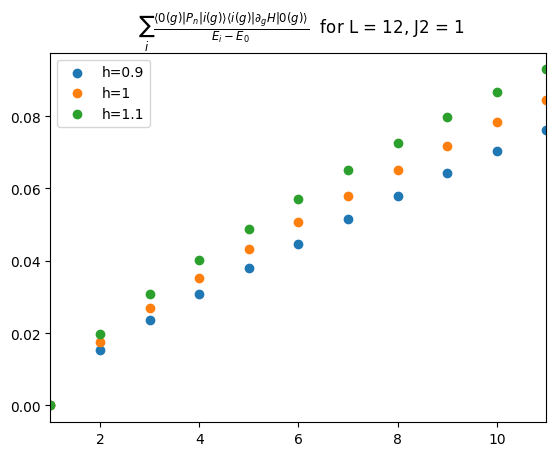

In [336]:
for i in range(3):
    x=[]
    for n in ns:
        x+=[(sum(P_basis[i][n-1,1:]*A_basis[i][1:]/(Es[i][1:]-Es[i][0])))]
    x=array(x)
    plt.scatter(ns,abs(x),label=f"h={h0_list[i]}" )
plt.xlim(ns[0],ns[-1])
plt.title(r" $\sum_i \frac{\langle 0(g)| P_n |i(g)\rangle \langle i(g) | \partial_g H | 0(g) \rangle }{E_i-E_0}$  "+f"for L = {L}, J2 = 1")
legend()

In [332]:
import numpy as np

def Com_array_for_basis(V):
    V0 = V[:, 0]                       # (D,)
    Nproj = len(Projectors)
    D = V.shape[1]

    com_expt = np.zeros((Nproj, D), dtype=float)

    AV = A @ V                         # compute once

    for n, Pi in enumerate(Projectors):
        print(n)
        # [A, Pi] V = A(Pi V) - Pi(AV)
        PiV  = Pi @ V                  # (D,D)
        comV = A @ PiV - Pi @ AV       # (D,D)

        # ⟨V0 | [A,Pi] | Vi⟩ for all i
        com_expt[n, :] = np.abs(np.conj(V0) @ comV)

    return com_expt



In [333]:
comutator = [Com_array_for_basis(V) for V in Vs]

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/1779517835.py:10: RuntimeWarning: divide by zero encountered in matmul
  AV = A @ V                         # compute once
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/1779517835.py:10: RuntimeWarning: overflow encountered in matmul
  AV = A @ V                         # compute once
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/1779517835.py:10: RuntimeWarning: invalid value encountered in matmul
  AV = A @ V                         # compute once


0


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/1779517835.py:15: RuntimeWarning: divide by zero encountered in matmul
  PiV  = Pi @ V                  # (D,D)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/1779517835.py:15: RuntimeWarning: overflow encountered in matmul
  PiV  = Pi @ V                  # (D,D)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/1779517835.py:15: RuntimeWarning: invalid value encountered in matmul
  PiV  = Pi @ V                  # (D,D)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/1779517835.py:16: RuntimeWarning: divide by zero encountered in matmul
  comV = A @ PiV - Pi @ AV       # (D,D)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/1779517835.py:16: RuntimeWarning: overflow encountered in matmul
  comV = A @ PiV - Pi @ AV       # (D,D)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_2671/1779517835.py:16: RuntimeWarning: invalid value encountered in matmul

1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10
0
1
2
3
4
5
6
7
8
9
10


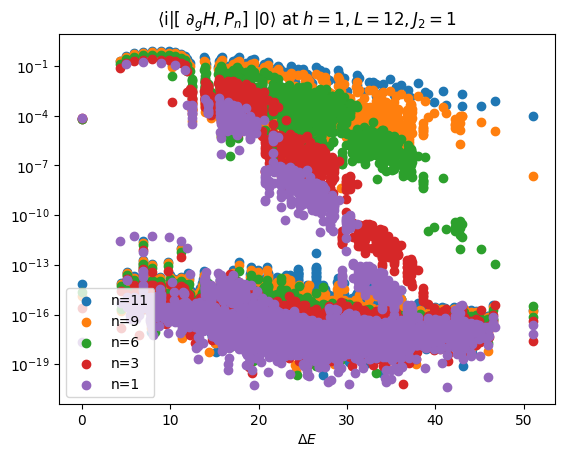

In [337]:
dE= Es[1]-Es[1][0]
plt.scatter(dE,comutator[1][-1,:],label=f"n={ns[-1]}")
plt.scatter(dE,comutator[1][-3,:],label=f"n={ns[-3]}")
plt.scatter(dE,comutator[1][-6,:],label=f"n={ns[-6]}")
plt.scatter(dE,comutator[1][-9,:],label=f"n={ns[-9]}")
plt.scatter(dE,comutator[1][-11,:],label=f"n={ns[-11]}")
yscale("log")
plt.title(r"$\langle$i|"+agp_string+r"$|0\rangle$ at $h=1, L = 12, J_2 = 1$")
xlabel(delta_string)
#xscale("log")
#plt.ylim(0.01,.4)
legend(loc="lower left")